In [39]:
import pandas as pd
import numpy as np



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
customer_features = pd.read_csv("customer_features.csv")

In [9]:
customer_features.head()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk
0,100018,46,81190,81190.0,1513,11.0,4.181818,0.018635,1765.000000,2016,8,28,2018-12-01,0.0,0,0
1,100102,51,68918,68918.0,1195,12.0,4.250000,0.017339,1351.333333,2013,3,69,2018-12-01,0.0,0,0
2,100140,47,72856,72856.0,593,11.0,4.272727,0.008139,1550.127660,2016,7,29,2018-11-01,1.0,0,0
3,100214,22,38236,38236.0,861,7.0,3.142857,0.022518,1738.000000,2015,8,40,2018-12-01,0.0,0,0
4,100272,37,54997,54997.0,1007,11.0,3.363636,0.018310,1486.405405,2014,1,59,2018-11-01,1.0,0,0


In [10]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loyalty Number                16737 non-null  int64  
 1   Total Flights                 16737 non-null  int64  
 2   Total Distance                16737 non-null  int64  
 3   Total Points Earned           16737 non-null  float64
 4   Total Points Redeemed         16737 non-null  int64  
 5   Active Months                 15167 non-null  float64
 6   Avg Flights per Active Month  15167 non-null  float64
 7   Redemption Ratio              16737 non-null  float64
 8   Avg Distance per Flight       16737 non-null  float64
 9   Enrollment Year               16737 non-null  int64  
 10  Enrollment Month              16737 non-null  int64  
 11  Loyalty Tenure (Months)       16737 non-null  int64  
 12  Last Flight Date              15167 non-null  object 
 13  M

In [11]:
customer_features.describe()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Months Since Last Flight,Churn,At Risk
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,15167.000000,15167.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,15167.000000,16737.000000,16737.000000
mean,549735.880445,30.400191,45579.359921,47592.100884,734.932903,8.638557,3.867168,0.016147,1361.353499,2015.253211,6.669116,38.292346,1.446298,0.123499,0.053713
std,258912.132453,16.865558,26092.338663,30391.859064,716.589736,2.813685,1.553721,0.025660,491.079062,1.979111,3.398958,23.605926,3.508961,0.329019,0.225458
min,100018.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,20.000000,28495.000000,28718.000000,0.000000,7.000000,3.090909,0.000000,1306.552632,2014.000000,4.000000,17.000000,0.000000,0.000000,0.000000
50%,550434.000000,34.000000,49445.000000,49885.000000,568.000000,9.000000,3.666667,0.011838,1473.711538,2015.000000,7.000000,37.000000,0.000000,0.000000,0.000000
75%,772019.000000,42.000000,62911.000000,63812.000000,1167.000000,11.000000,4.250000,0.023417,1620.576923,2017.000000,10.000000,59.000000,1.000000,0.000000,0.000000
max,999986.000000,106.000000,178858.000000,268287.000000,4479.000000,12.000000,24.000000,1.194352,2496.000000,2018.000000,12.000000,80.000000,23.000000,1.000000,1.000000


In [12]:
customer_features.isnull().sum()

,0
Loyalty Number,0
Total Flights,0
Total Distance,0
Total Points Earned,0
Total Points Redeemed,0
Active Months,1570
Avg Flights per Active Month,1570
Redemption Ratio,0
Avg Distance per Flight,0
Enrollment Year,0


In [13]:
customer_features[customer_features["Total Flights"] == 0].head(10)

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk
25,101356,0,0,0.0,0,NaN,NaN,0.0,0.0,2012,11,73,NaN,NaN,0,0
47,102308,0,0,0.0,0,NaN,NaN,0.0,0.0,2018,11,1,NaN,NaN,0,0
64,103352,0,0,0.0,0,NaN,NaN,0.0,0.0,2014,11,49,NaN,NaN,1,0
67,103383,0,0,0.0,0,NaN,NaN,0.0,0.0,2015,6,42,NaN,NaN,1,0
91,104739,0,0,0.0,0,NaN,NaN,0.0,0.0,2013,11,61,NaN,NaN,1,0
97,105145,0,0,0.0,0,NaN,NaN,0.0,0.0,2012,7,77,NaN,NaN,0,0
102,105352,0,0,0.0,0,NaN,NaN,0.0,0.0,2014,1,59,NaN,NaN,1,0
105,105700,0,0,0.0,0,NaN,NaN,0.0,0.0,2013,8,64,NaN,NaN,1,0
123,106589,0,0,0.0,0,NaN,NaN,0.0,0.0,2013,8,64,NaN,NaN,1,0
166,108481,0,0,0.0,0,NaN,NaN,0.0,0.0,2018,11,1,NaN,NaN,0,0


In [14]:
(customer_features["Total Flights"] == 0).sum()

np.int64(1570)

In [15]:
customer_features[customer_features["Total Flights"] == 0].head(10)

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk
25,101356,0,0,0.0,0,NaN,NaN,0.0,0.0,2012,11,73,NaN,NaN,0,0
47,102308,0,0,0.0,0,NaN,NaN,0.0,0.0,2018,11,1,NaN,NaN,0,0
64,103352,0,0,0.0,0,NaN,NaN,0.0,0.0,2014,11,49,NaN,NaN,1,0
67,103383,0,0,0.0,0,NaN,NaN,0.0,0.0,2015,6,42,NaN,NaN,1,0
91,104739,0,0,0.0,0,NaN,NaN,0.0,0.0,2013,11,61,NaN,NaN,1,0
97,105145,0,0,0.0,0,NaN,NaN,0.0,0.0,2012,7,77,NaN,NaN,0,0
102,105352,0,0,0.0,0,NaN,NaN,0.0,0.0,2014,1,59,NaN,NaN,1,0
105,105700,0,0,0.0,0,NaN,NaN,0.0,0.0,2013,8,64,NaN,NaN,1,0
123,106589,0,0,0.0,0,NaN,NaN,0.0,0.0,2013,8,64,NaN,NaN,1,0
166,108481,0,0,0.0,0,NaN,NaN,0.0,0.0,2018,11,1,NaN,NaN,0,0


Customer enrolled in the loyalty program but never took a single flight during the 2017–2018 observation period.

In [16]:
customer_features["Active Months"] = customer_features["Active Months"].fillna(0)

In [17]:
customer_features["Avg Flights per Active Month"] = (
    customer_features["Avg Flights per Active Month"].fillna(0)
)

In [18]:
# Column name "Ever Flown"
customer_features["Ever Flown"] = np.where(
    customer_features["Total Flights"] > 0,
    1,
    0
)

In [19]:
ml_data = customer_features[
    customer_features["Ever Flown"] == 1
].copy()

In [20]:
ml_data = customer_features[
    customer_features["Total Flights"] > 0
].copy()

ml_data.head()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk,Ever Flown
0,100018,46,81190,81190.0,1513,11.0,4.181818,0.018635,1765.000000,2016,8,28,2018-12-01,0.0,0,0,1
1,100102,51,68918,68918.0,1195,12.0,4.250000,0.017339,1351.333333,2013,3,69,2018-12-01,0.0,0,0,1
2,100140,47,72856,72856.0,593,11.0,4.272727,0.008139,1550.127660,2016,7,29,2018-11-01,1.0,0,0,1
3,100214,22,38236,38236.0,861,7.0,3.142857,0.022518,1738.000000,2015,8,40,2018-12-01,0.0,0,0,1
4,100272,37,54997,54997.0,1007,11.0,3.363636,0.018310,1486.405405,2014,1,59,2018-11-01,1.0,0,0,1


In [21]:
ml_data.isnull().sum()

,0
Loyalty Number,0
Total Flights,0
Total Distance,0
Total Points Earned,0
Total Points Redeemed,0
Active Months,0
Avg Flights per Active Month,0
Redemption Ratio,0
Avg Distance per Flight,0
Enrollment Year,0


Feature Selection

In [22]:
corr_matrix = ml_data.corr(numeric_only=True)

corr_matrix

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Months Since Last Flight,Churn,At Risk,Ever Flown
Loyalty Number,1.000000,-0.004297,-0.002674,-0.006649,0.008273,-0.001994,-0.009991,0.006166,-0.000162,0.009460,0.003027,-0.010006,0.000009,0.002530,-0.002299,NaN
Total Flights,-0.004297,1.000000,0.952787,0.904291,0.318350,0.720765,0.656713,-0.139065,-0.029510,-0.329835,-0.158228,0.356472,-0.360320,-0.288815,-0.337466,NaN
Total Distance,-0.002674,0.952787,1.000000,0.947236,0.303965,0.685893,0.624683,-0.156621,0.214978,-0.315239,-0.150852,0.340643,-0.343137,-0.273115,-0.321894,NaN
Total Points Earned,-0.006649,0.904291,0.947236,1.000000,0.206296,0.496966,0.774418,-0.171785,0.194522,-0.147922,-0.209908,0.179915,-0.300319,-0.215115,-0.283972,NaN
Total Points Redeemed,0.008273,0.318350,0.303965,0.206296,1.000000,0.412135,0.024662,0.464445,-0.018234,-0.268201,-0.004077,0.271886,-0.160480,-0.162006,-0.155820,NaN
Active Months,-0.001994,0.720765,0.685893,0.496966,0.412135,1.000000,0.032093,-0.044428,-0.039064,-0.544826,-0.031000,0.555590,-0.365567,-0.333492,-0.328781,NaN
Avg Flights per Active Month,-0.009991,0.656713,0.624683,0.774418,0.024662,0.032093,1.000000,-0.181610,-0.008719,0.097467,-0.228838,-0.065577,-0.174999,-0.069787,-0.175570,NaN
Redemption Ratio,0.006166,-0.139065,-0.156621,-0.171785,0.464445,-0.044428,-0.181610,1.000000,-0.148655,-0.011508,0.037302,0.006259,0.035096,0.008610,0.025041,NaN
Avg Distance per Flight,-0.000162,-0.029510,0.214978,0.194522,-0.018234,-0.039064,-0.008719,-0.148655,1.000000,0.014155,0.003841,-0.014872,0.012176,0.011413,0.006214,NaN
Enrollment Year,0.009460,-0.329835,-0.315239,-0.147922,-0.268201,-0.544826,0.097467,-0.011508,0.014155,1.000000,-0.150891,-0.989777,0.023013,0.102076,0.038289,NaN


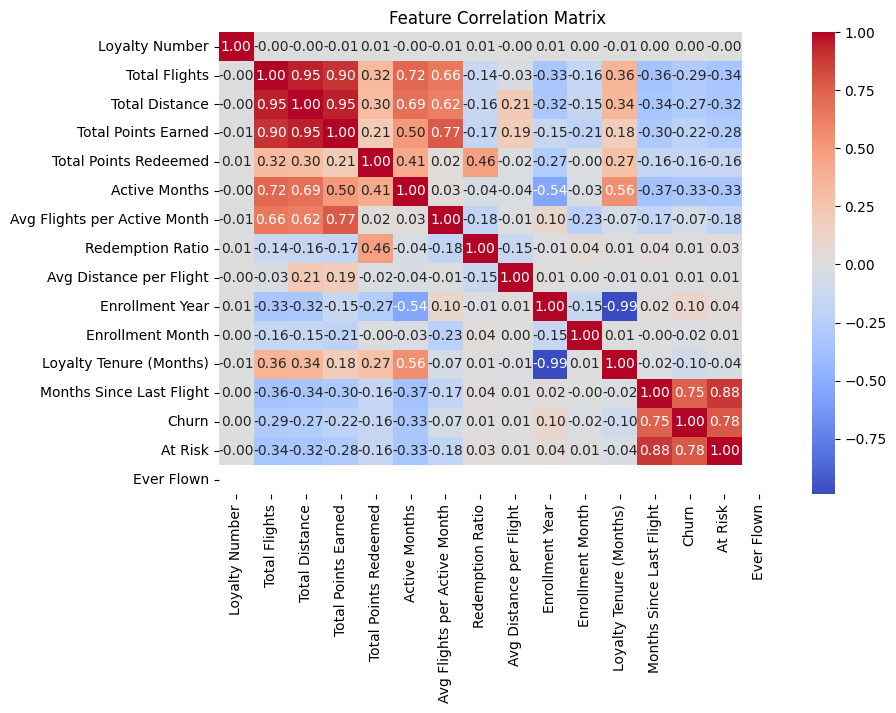

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6
                    ))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

Instead of
Churn =
Months Since Last Flight >= 6
we will use
Churn =
Cancellation Year is not null
To prevent data leakage

---------------------------------------
Machine Learning

In [24]:
X = ml_data[
    [
        "Total Flights",
        "Total Distance",
        "Total Points Redeemed",
        "Active Months",
        "Avg Flights per Active Month",
        "Redemption Ratio",
        "Avg Distance per Flight",
        "Loyalty Tenure (Months)",
        "Months Since Last Flight"
    ]
]

y = ml_data["Churn"]

In [25]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (15167, 9)
Shape of y: (15167,)


In [26]:
ml_data.to_csv("ml_data.csv", index=False)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (12133, 9)
Testing Set : (3034, 9)


In [29]:
print("Training Churn Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Churn Distribution:
Churn
0    92.639908
1     7.360092
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
0    92.649967
1     7.350033
Name: proportion, dtype: float64


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [31]:
print(X_train_scaled[:5])

[[ 0.23652805  0.16879164 -0.37705311  1.1971092  -0.50886358 -0.29315244
  -0.16226052  1.59404687 -0.41507117]
 [-0.31560775 -0.0769588  -1.14225733  0.13051488 -0.41878896 -0.66888965
   0.74019037  1.63700797 -0.41507117]
 [ 0.51259595  0.97859912 -1.14225733  0.13051488  0.44592736 -0.66888965
   1.1496499   0.52001943 -0.41507117]
 [ 0.0984941  -0.25788773  0.3430562   0.84157776 -0.44499249  0.2197606
  -0.99123349  1.76589126 -0.41507117]
 [ 0.85768083  0.90591114 -0.31081997 -1.29161088  3.45802256 -0.46107988
   0.17257683 -1.24138558 -0.12693417]]


LOGISTIC REGRESSION

In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [33]:
y_pred = log_model.predict(X_test_scaled)

In [34]:
print(y_pred[:20])


[1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.974950560316414


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2796   15]
 [  61  162]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2811
           1       0.92      0.73      0.81       223

    accuracy                           0.97      3034
   macro avg       0.95      0.86      0.90      3034
weighted avg       0.97      0.97      0.97      3034



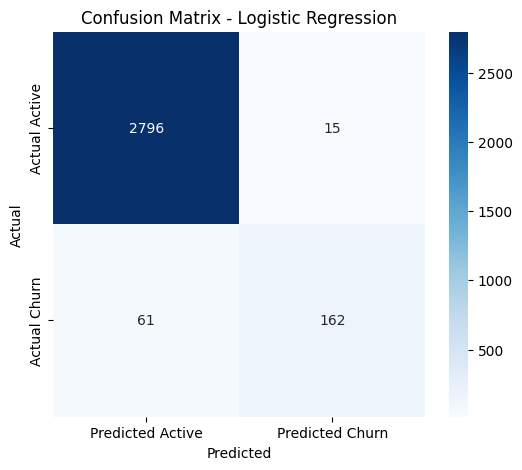

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Active", "Predicted Churn"],
    yticklabels=["Actual Active", "Actual Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The Logistic Regression model achieved an accuracy of 97.5%, with a precision of 92% and a recall of 73%. While the model correctly identified most non-churning customers, it also detected nearly three-quarters of actual churn cases. The high precision indicates that retention efforts would be focused on customers who are genuinely at risk, minimizing unnecessary marketing costs.

----------------------------------------------
Default Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [48]:
dt_pred = dt_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")

print(classification_report(y_test, dt_pred))

Accuracy: 0.966381015161503

Confusion Matrix
[[2750   61]
 [  41  182]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2811
           1       0.75      0.82      0.78       223

    accuracy                           0.97      3034
   macro avg       0.87      0.90      0.88      3034
weighted avg       0.97      0.97      0.97      3034



Tuned Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt_model2 = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_model2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [51]:
dt_pred2 = dt_model2.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, dt_pred2))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, dt_pred2))

print("\nClassification Report")

print(classification_report(y_test, dt_pred2))

Accuracy: 0.981542518127884

Confusion Matrix
[[2794   17]
 [  39  184]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2811
           1       0.92      0.83      0.87       223

    accuracy                           0.98      3034
   macro avg       0.95      0.91      0.93      3034
weighted avg       0.98      0.98      0.98      3034



In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"]
}

In [64]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [65]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 10, 20]},
             scoring='f1')

In [66]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [67]:
print("Best Cross Validation F1 Score:")
print(grid_search.best_score_)

Best Cross Validation F1 Score:
0.8238571888119264


In [68]:
best_dt = grid_search.best_estimator_

In [69]:
best_pred = best_dt.predict(X_test)

In [70]:
print("Accuracy:", accuracy_score(y_test, best_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report")
print(classification_report(y_test, best_pred))

Accuracy: 0.981542518127884

Confusion Matrix
[[2801   10]
 [  46  177]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2811
           1       0.95      0.79      0.86       223

    accuracy                           0.98      3034
   macro avg       0.97      0.90      0.93      3034
weighted avg       0.98      0.98      0.98      3034



Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [55]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
rf_pred = rf_model.predict(X_test)

In [57]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.9805537244561635

Confusion Matrix
[[2798   13]
 [  46  177]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2811
           1       0.93      0.79      0.86       223

    accuracy                           0.98      3034
   macro avg       0.96      0.89      0.92      3034
weighted avg       0.98      0.98      0.98      3034



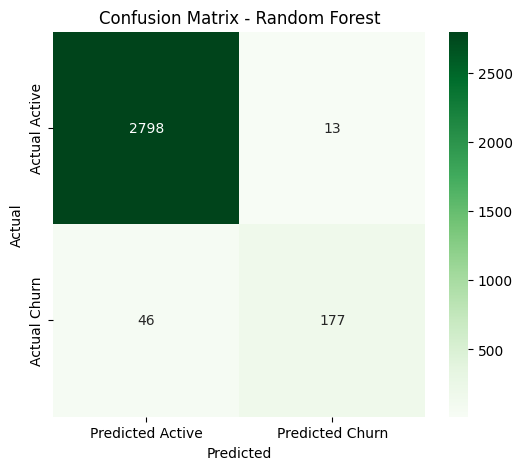

In [59]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted Active", "Predicted Churn"],
    yticklabels=["Actual Active", "Actual Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC curve

In [71]:
y_prob = dt_model2.predict_proba(X_test)[:, 1]

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", round(auc,3))

AUC Score: 0.973


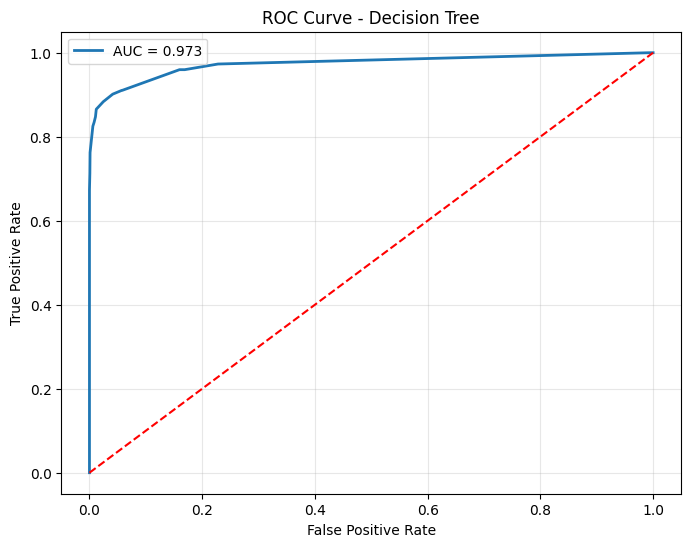

In [73]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### ROC Curve

The ROC Curve evaluates the model across different classification thresholds.

The Area Under the Curve (AUC) measures the model's ability to distinguish between churned and non-churned customers.

A higher AUC indicates better classification performance.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model2.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,Months Since Last Flight,0.873191
7,Loyalty Tenure (Months),0.113108
4,Avg Flights per Active Month,0.011468
3,Active Months,0.001702
1,Total Distance,0.000531
0,Total Flights,0.000000
2,Total Points Redeemed,0.000000
6,Avg Distance per Flight,0.000000
5,Redemption Ratio,0.000000


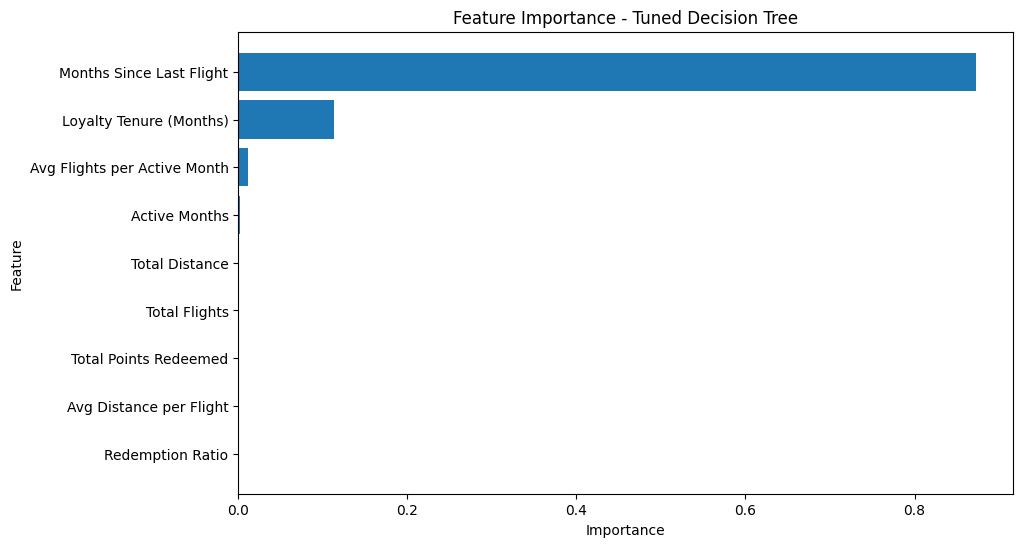

In [61]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## Feature Importance Analysis

The Decision Tree identified **Months Since Last Flight** as the most influential feature for predicting customer churn, contributing approximately **87%** of the model's decision-making process.

The second most important feature was **Loyalty Tenure (Months)**, indicating that the duration of a customer's relationship with the airline also influences cancellation behavior.

Other behavioral features such as flight frequency, active months, and travel distance had relatively small contributions. This suggests that **recent customer inactivity** is a much stronger indicator of churn than historical travel behavior.

### Business Insight

Customers who have not flown for an extended period should be prioritized for retention campaigns. Monitoring customer inactivity can help airlines intervene before customers decide to cancel their loyalty membership.

EXPERIMENT

In [74]:
X_without_last_flight = X.drop(
    columns=["Months Since Last Flight"]
)

X_without_last_flight.head()

,Total Flights,Total Distance,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Loyalty Tenure (Months)
0,46,81190,1513,11.0,4.181818,0.018635,1765.000000,28
1,51,68918,1195,12.0,4.250000,0.017339,1351.333333,69
2,47,72856,593,11.0,4.272727,0.008139,1550.127660,29
3,22,38236,861,7.0,3.142857,0.022518,1738.000000,40
4,37,54997,1007,11.0,3.363636,0.018310,1486.405405,59


In [75]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_without_last_flight,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
dt_no_last = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_no_last.fit(X_train2, y_train2)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [77]:
pred_no_last = dt_no_last.predict(X_test2)

In [78]:
print("Accuracy:", accuracy_score(y_test2, pred_no_last))

print("\nConfusion Matrix")
print(confusion_matrix(y_test2, pred_no_last))

print("\nClassification Report")
print(classification_report(y_test2, pred_no_last))

Accuracy: 0.96044825313118

Confusion Matrix
[[2788   23]
 [  97  126]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2811
           1       0.85      0.57      0.68       223

    accuracy                           0.96      3034
   macro avg       0.91      0.78      0.83      3034
weighted avg       0.96      0.96      0.96      3034



###Table 1: Machine Learning Model Performance Comparison

In [80]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (Default)",
        "Decision Tree (Tuned)",
        "Random Forest",
        "Decision Tree (GridSearchCV)"
    ],
    "Accuracy": [0.9750, 0.9664, 0.9815, 0.9806, 0.9815],
    "Precision": [0.92, 0.75, 0.92, 0.93, 0.95],
    "Recall": [0.73, 0.82, 0.83, 0.79, 0.79],
    "F1 Score": [0.81, 0.78, 0.87, 0.86, 0.86]
})

comparison = comparison.sort_values(by="F1 Score", ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
2,Decision Tree (Tuned),0.9815,0.92,0.83,0.87
4,Decision Tree (GridSearchCV),0.9815,0.95,0.79,0.86
3,Random Forest,0.9806,0.93,0.79,0.86
0,Logistic Regression,0.9750,0.92,0.73,0.81
1,Decision Tree (Default),0.9664,0.75,0.82,0.78


###Ablation Study

To evaluate the importance of customer inactivity, an ablation study was performed by removing the Months Since Last Flight feature and retraining the Decision Tree model.

###Findings
Accuracy decreased from 98.15% to 96.04%.
Recall dropped from 83% to 57%.
The number of missed churning customers increased from 39 to 97.
Business Insight

These results indicate that customer inactivity is the strongest behavioral indicator of churn. Monitoring the time since a customer's last flight enables the airline to identify at-risk customers more effectively and intervene before cancellation.

### Model Comparison

Five machine learning models were evaluated for customer churn prediction.

Among them, the manually tuned Decision Tree achieved the best overall balance of accuracy, precision, recall, and F1-score. It correctly identified 83% of churning customers while maintaining an overall accuracy of 98.15%.

Although the Random Forest achieved slightly higher precision (93%), its recall was lower than the tuned Decision Tree. Since customer retention is the primary business objective, the tuned Decision Tree was selected as the final model because it minimizes missed churn cases.

###Table 2: Ablation Study: Impact of Removing "Months Since Last Flight"

In [81]:
ablation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives"
    ],
    "With 'Months Since Last Flight'": [
        98.15,
        92,
        83,
        87,
        17,
        39
    ],
    "Without 'Months Since Last Flight'": [
        96.04,
        85,
        57,
        68,
        23,
        97
    ]
})

ablation

,Metric,With 'Months Since Last Flight',Without 'Months Since Last Flight'
0,Accuracy,98.15,96.04
1,Precision,92.00,85.00
2,Recall,83.00,57.00
3,F1 Score,87.00,68.00
4,False Positives,17.00,23.00
5,False Negatives,39.00,97.00


### Ablation Study

To understand the importance of customer inactivity, the feature **Months Since Last Flight** was removed and the model was retrained.

The results showed a significant decline in model performance:

- Accuracy decreased from **98.15%** to **96.04%**.
- Recall dropped from **83%** to **57%**.
- The number of missed churning customers increased from **39** to **97**.

This confirms that customer inactivity is the strongest predictor of churn in the airline loyalty program. Monitoring inactive customers and engaging them through personalized retention campaigns can significantly improve customer retention.

###"Among the evaluated models, the manually tuned Decision Tree provided the best balance between accuracy (98.15%), precision (92%), recall (83%), and interpretability. It was therefore selected as the final model for deployment."